# Logistic Regression

## 1. Problem Satement
- The goal of this project is to build a Logistic Regression model that predicts whether a user will subscribe to a premium fitness app based on their demographic details, workout habits, and app usage behavior.

# 2. Objectives

- Analyze and understand the dataset (numerical + categorical features)
- Perform data preprocessing (encoding and scaling)
- Build a Logistic Regression model
- Evaluate model performance using metrics like accuracy, precision, recall, and F1-score
- Predict whether a user will subscribe or not
- Derive insights to improve business decisions

# 3. Import Require Libraries

In [31]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# 4.Collect and Load Data

In [41]:
df = pd.read_csv("Fitness_subscription_dataset.csv")
df.head(10)

,User_ID,Age,Monthly_Income,Workout_Frequency,Preferred_Workout,Diet_Type,Fitness_Level,App_Usage_Time,Trial_Days_Used,Device_Type,Subscription
0,U0238,23,34061,6,Yoga,Vegan,Advanced,49,13,Android,0
1,U0019,27,18986,5,Crossfit,Keto,Intermediate,7,10,Android,1
2,U0281,22,56081,5,Yoga,Non-Veg,Advanced,80,8,iOS,1
3,U0508,49,68493,1,Cardio,Vegetarian,Intermediate,44,1,iOS,0
4,U0428,39,40873,3,Strength,Keto,Intermediate,45,1,Android,0
5,U0264,45,87841,2,Crossfit,Vegetarian,Beginner,15,8,iOS,0
6,U0132,32,15000,3,Strength,Non-Veg,Advanced,7,1,iOS,0
7,U0116,21,79332,1,Strength,Non-Veg,Intermediate,93,6,Android,1
8,U0258,29,44437,0,Strength,Keto,Beginner,72,2,iOS,0
9,U0557,46,49409,2,Yoga,Vegan,Intermediate,80,6,iOS,1


# 5. Seperate Feature & Target

In [33]:
X = df.drop(["Subscription","User_ID"],axis=1)
y= df["Subscription"]

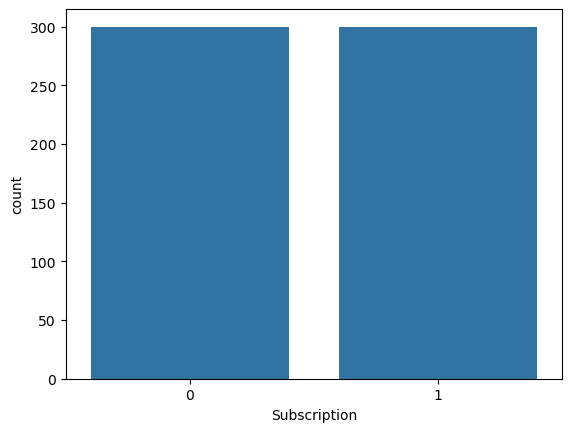

In [53]:
import seaborn as sns
sns.countplot(x=y)
plt.show()

# 6. Split Data

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# 7.Preprocessing

### Pipeline

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
num_cols = ["Age","Monthly_Income","Workout_Frequency","App_Usage_Time","Trial_Days_Used"]

In [37]:
preprocessor = ColumnTransformer([
    ("Preferred_Workout",OneHotEncoder(),["Preferred_Workout"]),
    ("Diet_Type",OneHotEncoder(),["Diet_Type"]),
    ("Fitness_Level",OrdinalEncoder(categories=[["Advanced","Intermediate","Beginner"]]),["Fitness_Level"]),
    ("Device_Type",OrdinalEncoder(categories=[["iOS","Android"]]),["Device_Type"]),
    ("num_cols",StandardScaler(),num_cols)
],
remainder="drop"
)



In [38]:
Pipeline = Pipeline([
    ("Preprocessing",preprocessor),
    ("Model",LogisticRegression())
])

# 8. Train Model

In [39]:
Pipeline.fit(X_train,y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Preferred_Workout',
                                                  OneHotEncoder(),
                                                  ['Preferred_Workout']),
                                                 ('Diet_Type', OneHotEncoder(),
                                                  ['Diet_Type']),
                                                 ('Fitness_Level',
                                                  OrdinalEncoder(categories=[['Advanced',
                                                                              'Intermediate',
                                                                              'Beginner']]),
                                                  ['Fitness_Level']),
                                                 ('Device_Type',
                                                  OrdinalEncoder(categories=[['iOS',
                                                                              'Android']]),
                                                  ['Device_Type']),
                                                 ('num_cols', StandardScaler(),
                                                  ['Age', 'Monthly_Income',
                                                   'Workout_Frequency',
                                                   'App_Usage_Time',
                                                   'Trial_Days_Used'])])),
                ('Model', LogisticRegression())])

# 9.Predict 

In [40]:
y_pred = Pipeline.predict(X_test)
print(y_pred)

[0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 0 1
 1 1 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0]


### Manual prediction

In [46]:
new_check = pd.DataFrame([{
    "Age":49,
    "Monthly_Income":68493,
    "Workout_Frequency":1,
    "Preferred_Workout":"Cardio",
    "Diet_Type":"Vegetarian",
    "Fitness_Level":"Intermediate",
    "App_Usage_Time":44 ,
    "Trial_Days_Used":1  ,
    "Device_Type": "iOS" 
    
    
}])

Pipeline.predict(new_check)

array([0])

# 10. Model Evaluation

In [51]:
from sklearn.metrics import accuracy_score,classification_report

print("accuracy_score:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred,output_dict=True))

accuracy_score: 0.75
{'0': {'precision': 0.7230769230769231, 'recall': 0.7966101694915254, 'f1-score': 0.7580645161290323, 'support': 59.0}, '1': {'precision': 0.7818181818181819, 'recall': 0.7049180327868853, 'f1-score': 0.7413793103448276, 'support': 61.0}, 'accuracy': 0.75, 'macro avg': {'precision': 0.7524475524475525, 'recall': 0.7507641011392053, 'f1-score': 0.7497219132369299, 'support': 120.0}, 'weighted avg': {'precision': 0.752937062937063, 'recall': 0.75, 'f1-score': 0.7495828698553949, 'support': 120.0}}


# 11. Insights
- Users with higher app usage time are more likely to subscribe
- Workout frequency shows strong positive impact on subscription behavior
- User engagement > income in predicting subscriptions
- Intermediate fitness level users tend to convert more than beginners or advanced
- Diet type plays a role in identifying health-conscious users
- Device type (iOS/Android) has a minor but noticeable influence
- Model shows higher recall (0.79) → captures most potential subscribers
- Slightly lower precision (0.72) → some false positives exist
- Balanced dataset (50–50) helped achieve stable and unbiased predictions
- Logistic Regression provides interpretable results (easy to explain feature impact)
- Model is suitable for marketing targeting and user segmentation
- Current performance (75% accuracy) is good but can be improved with advanced models

# 12.Conclusion
- This project successfully developed a Logistic Regression model to predict user subscription behavior in a fitness app using a mix of numerical and categorical features.
The pipeline handled:
- ✅ Data preprocessing (encoding + scaling)
- ✅ Model training
- ✅ Evaluation using multiple metrics


The model achieved:
- Accuracy: 75%
- Precision: 72%
- Recall: 79%
- F1 Score: 75%
- These results indicate a balanced and reliable model that performs consistently across different evaluation measures.